This file containes 10000 entries that range from 20.0 Gev to 40.0 Gev.


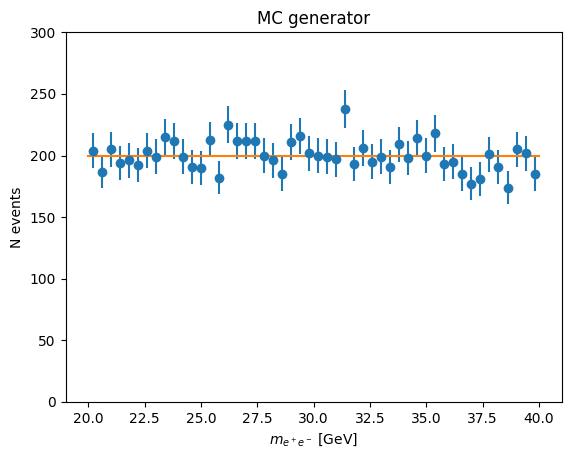

<Figure size 640x480 with 0 Axes>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
import random
from scipy.optimize import curve_fit
from scipy.special import erfcinv
import scipy.stats as st

# Problem 1
with open('LHC_data_2021.txt', 'r') as f:
    lines = (line.strip() for line in f if line)
    real_data = [float(line) for line in lines]

print(f"This file containes {len(real_data)} entries that range from {min(real_data)} Gev to {max(real_data)} Gev.")

def pdf_theory(x, constant):
    return 0*x + constant



# Problem 2
# MC toy data for bump hunting
N_entries = len(real_data)
N_bins = int(N_entries/200)

bkg = np.random.uniform(20,40,N_entries)

counts,bin_edges = np.histogram(bkg,N_bins)
bin_centres = (bin_edges[:-1] + bin_edges[1:])/2.
err = np.sqrt(counts)

plt.title("MC generator")
plt.errorbar(bin_centres, counts, yerr=err, fmt='o')
plt.ylim(0, 300)
plt.xlabel('$m_{e^+e^-}$ [GeV]')
plt.ylabel('N events')

m = np.linspace(min(real_data), max(real_data), 1000)
pdf = pdf_theory(m, N_entries/N_bins)
plt.plot(m,pdf)


plt.savefig("E3_Problem_2.pdf")
plt.show()
plt.clf()

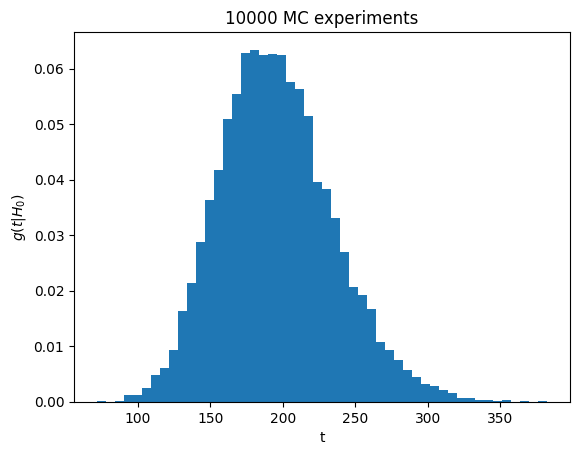

<Figure size 640x480 with 0 Axes>

In [3]:
# Problem 3
def chi_2(func, const, data_x, data_y):
    chi2 = 0.
    for x,y in zip(data_x,data_y):
        chi2 += (func(x,const) - y)**2
    return chi2/len(data_x)

chi_2_histo = []

N_MC_experiments = int(1e4)
for i in range(N_MC_experiments):
    bkg = np.random.uniform(20,40,N_entries)
    counts,bin_edges = np.histogram(bkg,N_bins)
    bin_centres = (bin_edges[:-1] + bin_edges[1:])/2.

    chi_2_histo.append(chi_2(pdf_theory, N_entries/N_bins, bin_centres, counts))

weights = np.ones_like(chi_2_histo)/len(chi_2_histo)

N_bins_chi2 = 50

plt.hist(chi_2_histo, weights=weights, bins = N_bins_chi2)
plt.title(f"{N_MC_experiments} MC experiments")
plt.xlabel("t")
plt.ylabel("$g(t|H_0)$")
plt.savefig("E3_Problem_3.pdf")
plt.show()
plt.clf()

For 5 sigma significance, t_critical = 379.49


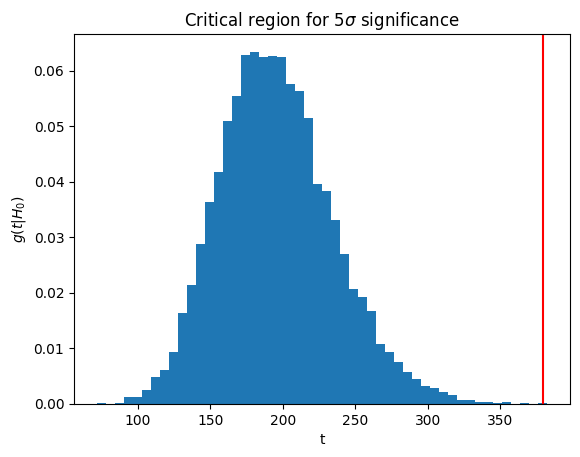

<Figure size 640x480 with 0 Axes>

In [7]:
# Problem 4
counts_test, bin_edges_test = np.histogram(chi_2_histo,N_bins_chi2)
bin_centres_test = (bin_edges_test[:-1] + bin_edges_test[1:])/2.

n_sigma_significance = 5

def sigma_to_pvalue(sigma):
    return 1.0 - st.norm.cdf(sigma)

for i in range(N_bins_chi2):
    p = (sum(counts_test[i:N_bins_chi2])/sum(counts_test))
    if p < sigma_to_pvalue(n_sigma_significance):
        index = i
        break
print(f"For {n_sigma_significance} sigma significance, t_critical = {bin_centres_test[i]:.2f}")

plt.hist(chi_2_histo, weights=weights, bins = N_bins_chi2)
plt.axvline(x = bin_centres_test[i], color = 'r', label = '$t_{critical}$')
plt.title(f"Critical region for {n_sigma_significance}$\sigma$ significance")
plt.xlabel("t")
plt.ylabel("$g(t|H_0)$")
plt.savefig("E3_Problem_4.pdf")
plt.show()
plt.clf()


t_obs = 301.24


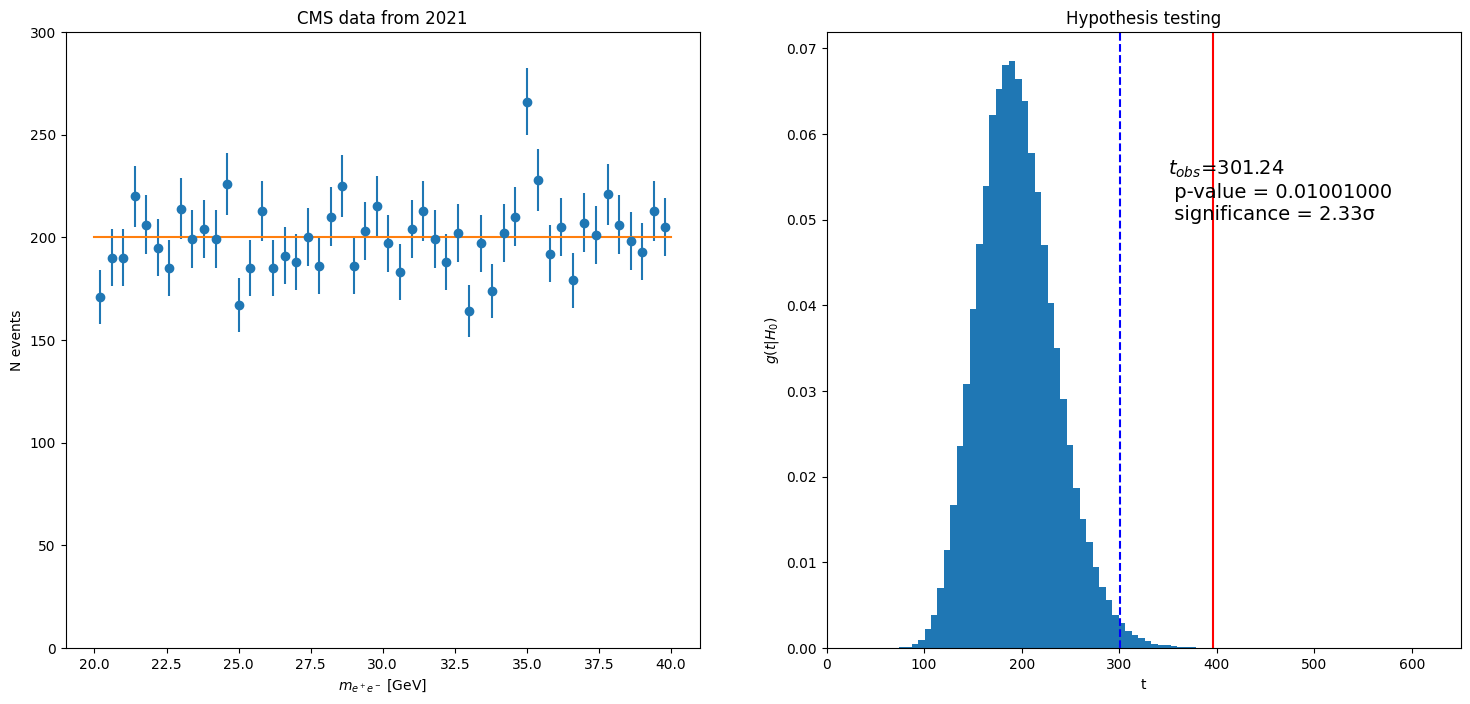

<Figure size 640x480 with 0 Axes>

In [ ]:
# Problem 5
counts_obs,bin_edges_obs = np.histogram(real_data, N_bins)
bin_centres_obs = (bin_edges_obs[:-1] + bin_edges_obs[1:])/2.

err = np.sqrt(counts_obs)

m = np.linspace(min(real_data), max(real_data), 1000)
pdf = pdf_theory(m, N_entries/N_bins)

figure, axis = plt.subplots(ncols=2,figsize=(18,8))
axis[0].errorbar(bin_centres_obs, counts_obs, yerr=err, fmt='o')
axis[0].set_ylim(0, 300)
axis[0].set_title("CMS data from 2021")
axis[0].set(xlabel='$m_{e^+e^-}$ [GeV]',ylabel='N events')
axis[0].plot(m,pdf)

t_obs = chi_2(pdf_theory, N_entries/N_bins, bin_centres_obs, counts_obs)
print(f"t_obs = {t_obs:.2f}")
index = np.argmin(np.abs(np.array(bin_centres_test)-t_obs))
p_value = (sum(counts_test[index:N_bins_chi2])/sum(counts_test))

def significance(p_value):
    return np.sqrt(2)*erfcinv(2*p_value)

text = "$t_{obs}$"+f"={t_obs:.2f}\n p-value = {p_value:.8f}\n significance = {significance(p_value):.2f}σ"
axis[1].hist(chi_2_histo, weights=weights, bins = N_bins_chi2)
axis[1].axvline(x = bin_centres_test[i], color = 'r', label = '$t_{critical}$')
axis[1].axvline(x = t_obs, color = 'b', linestyle='--', label = '$t_{obs}$')
axis[1].set_title("Hypothesis testing")
axis[1].set(xlabel="t", ylabel="$g(t|H_0)$")
axis[1].text(350,0.05,text,fontsize=14)
axis[1].set_xlim([0, 650])
plt.savefig("E3_Problem_5.pdf")
plt.show()
plt.clf()